<a href="https://colab.research.google.com/github/BackgroundTree/web3-creature-collector/blob/ahmed/spleen_segmentation_hpc_pipeline_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫁 Spleen Segmentation & Parallel 3D Reconstruction Pipeline
### End-to-End: MONAI AI Segmentation → MPI + Numba HPC → Streamlit Deployment

---

| Phase | Description | Crash-Safe? |
|-------|-------------|-------------|
| **1** | Environment & Directory Setup | ✅ |
| **2A** | Dataset Fingerprinting | ✅ saves JSON |
| **2B** | Preprocessing → `.npy` cache | ✅ skip-if-exists |
| **2C** | 3D Attention U-Net (MONAI) | ✅ |
| **2D** | Training — DiceCE, AdamW, AMP | ✅ auto-resume |
| **2E** | Inference — Sliding-window + 8-flip TTA | ✅ saves NIfTI |
| **3** | Parallel 3D Reconstruction (MPI + Numba) | ✅ |
| **4** | Streamlit Interactive Dashboard | ✅ |

> **Target Organ:** Spleen · **Classes:** `0` Background · `1` Spleen  
> **Dataset path:** `/content/drive/MyDrive/AID323_Project/Dataset/`  
> **Runtime:** GPU (T4 or better) · Enable: `Runtime → Change runtime type → T4 GPU`


---
## ⚙️ Phase 1 — Environment & Directory Setup

Install all required libraries, mount Google Drive, and scaffold the full
directory tree. Every subsequent phase writes output into these directories,
creating a clean and reproducible workspace.


### 1A · Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted successfully')


Mounted at /content/drive
✅ Google Drive mounted successfully


### 1B · Install Dependencies

We install:
- **MONAI[all]** — Medical Open Network for AI (includes MONAI transforms, networks, metrics)
- **mpi4py** — Python bindings for MPI (distributed-memory parallelism)
- **numba** — JIT-compiler for shared-memory parallel kernels (`@njit`)
- **nibabel** — Read/write NIfTI medical imaging files
- **scikit-image** — Marching Cubes for mesh generation
- **trimesh + plotly** — 3D mesh loading and interactive rendering in Streamlit
- **streamlit** — Web UI framework for the performance dashboard


In [2]:
import subprocess, sys

print("📦 Installing system packages (OpenMPI)...")
subprocess.run(["apt-get", "install", "-y", "-q", "openmpi-bin", "libopenmpi-dev"], check=True)

print("📦 Installing Python packages...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "monai[all]", "nibabel", "scikit-image", "trimesh", "plotly",
    "streamlit", "mpi4py", "numba", "torchinfo", "scipy",
], check=True)

subprocess.run(["npm", "install", "-g", "localtunnel"], check=True, capture_output=True)

print("✅ All packages installed successfully")


📦 Installing system packages (OpenMPI)...
📦 Installing Python packages...
✅ All packages installed successfully


### 1C · Core Imports

In [3]:
import os, sys, json, glob, random, time, warnings, subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import torch
import torch.nn as nn
from tqdm import tqdm
from scipy.ndimage import zoom

from monai.transforms import (
    Compose,
    RandCropByPosNegLabeld, RandFlipd, RandRotate90d,
    RandGaussianNoised, RandGaussianSmoothd,
    RandShiftIntensityd, EnsureTyped, AsDiscrete,
)
from monai.data import CacheDataset, DataLoader, decollate_batch
from monai.networks.nets import AttentionUnet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism

warnings.filterwarnings("ignore")
set_determinism(seed=42)

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


### 1D · GPU Adaptive Configuration

In [4]:
assert torch.cuda.is_available(), (
    "❌ No GPU detected! Go to: Runtime → Change runtime type → Hardware accelerator → GPU"
)

vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9

# Adaptive settings based on VRAM
if vram_gb >= 38:        # A100
    BATCH_SIZE, PATCH_SIZE = 4, [128, 128, 128]
elif vram_gb >= 14:      # V100 / T4 Pro
    BATCH_SIZE, PATCH_SIZE = 2, [96, 96, 96]
else:                    # T4 standard (~15 GB)
    BATCH_SIZE, PATCH_SIZE = 2, [96, 96, 96]

print(f"VRAM          : {vram_gb:.1f} GB")
print(f"BATCH_SIZE    : {BATCH_SIZE}")
print(f"PATCH_SIZE    : {PATCH_SIZE}")


VRAM          : 15.6 GB
BATCH_SIZE    : 2
PATCH_SIZE    : [96, 96, 96]


### 1E · Global Configuration & Directory Tree

In [5]:
# ── Dataset Configuration ────────────────────────────────────────────────────
N_CLASSES     = 2          # Background=0, Spleen=1
ORGAN_NAME    = "spleen"
MAX_EPOCHS    = 300
VAL_INTERVAL  = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5
SW_OVERLAP    = 0.5        # Sliding-window overlap ratio

# ── Paths ────────────────────────────────────────────────────────────────────
RAW_DATA_DIR = "/content/drive/MyDrive/AID323_Project/Dataset"

BASE = "/content/drive/MyDrive/AID323_Project"

DIRS = {
    "fingerprint"  : f"{BASE}/fingerprint",
    "prep_images"  : f"{BASE}/preprocessed/images",
    "prep_labels"  : f"{BASE}/preprocessed/labels",
    "checkpoints"  : f"{BASE}/checkpoints",
    "logs"         : f"{BASE}/logs",
    "predictions"  : f"{BASE}/predictions",
    "output_meshes": "/content/Output_Meshes",
}

LOCAL_DIRS = {
    "output_meshes": "/content/Output_Meshes",
    "logs"         : "/content/logs",
}

for name, path in {**DIRS, **LOCAL_DIRS}.items():
    os.makedirs(path, exist_ok=True)
    print(f"  ✓  {path}")

print("\n✅ Directory tree ready")


  ✓  /content/drive/MyDrive/AID323_Project/fingerprint
  ✓  /content/drive/MyDrive/AID323_Project/preprocessed/images
  ✓  /content/drive/MyDrive/AID323_Project/preprocessed/labels
  ✓  /content/drive/MyDrive/AID323_Project/checkpoints
  ✓  /content/logs
  ✓  /content/drive/MyDrive/AID323_Project/predictions
  ✓  /content/Output_Meshes

✅ Directory tree ready


---
## 🔬 Phase 2A — Dataset Fingerprinting

**Core nnU-Net-inspired insight:** measure the dataset's intrinsic properties first,
then let those numbers drive *every* downstream decision automatically.
Nothing in the preprocessing and training phases is hardcoded — everything flows
from the `dataset_fingerprint.json` saved here.

| Measured statistic | How it drives downstream decisions |
|---|---|
| Median voxel spacing | Resample target (mm) |
| 0.5 / 99.5 foreground percentiles | HU intensity clipping bounds |
| Foreground mean / std | Z-score normalization parameters |
| Per-class voxel counts | Loss-function class weights |
| Median volume shape | Patch-size heuristic |


In [6]:
import glob, subprocess, os

# ── Find the tar file anywhere on your Drive ─────────────────────────────────
hits = glob.glob("/content/drive/MyDrive/**/Task09_Spleen.tar", recursive=True)
assert hits, "❌ Task09_Spleen.tar not found — check the filename is exactly 'Task09_Spleen.tar'"
tar_path = hits[0]
print(f"✅ Found: {tar_path}")

# ── Extract into the Dataset folder ──────────────────────────────────────────
dest = "/content/drive/MyDrive/AID323_Project/Dataset"
os.makedirs(dest, exist_ok=True)

print("📦 Extracting... (may take 2–5 min over Drive)")
subprocess.run(
    ["tar", "-xf", tar_path, "-C", dest, "--strip-components=1"],
    check=True
)

# ── Verify ────────────────────────────────────────────────────────────────────
images = sorted(glob.glob(f"{dest}/imagesTr/*.nii.gz"))
labels = sorted(glob.glob(f"{dest}/labelsTr/*.nii.gz"))
print(f"\n✅ Done!")
print(f"   Images : {len(images)}")
print(f"   Labels : {len(labels)}")
assert images and labels, "❌ Extraction succeeded but files not found — check --strip-components"

✅ Found: /content/drive/MyDrive/AID323_Project/Dataset/Task09_Spleen.tar
📦 Extracting... (may take 2–5 min over Drive)

✅ Done!
   Images : 41
   Labels : 41


In [8]:
def build_data_pairs(raw_dir: str):
    """
    Discover image-label pairs from the MSD Task09 Spleen layout:
      raw_dir/imagesTr/*.nii.gz  ←→  raw_dir/labelsTr/*.nii.gz
    Returns a list of {'image': ..., 'label': ...} dicts, sorted by stem.
    """

    raw = Path(raw_dir)
    images = sorted(raw.rglob("imagesTr/*.nii.gz"))
    labels = sorted(raw.rglob("labelsTr/*.nii.gz"))

    assert images, f"No images found under {raw_dir}/imagesTr/"
    assert labels, f"No labels found under {raw_dir}/labelsTr/"
    assert len(images) == len(labels), (
        f"Image/label count mismatch: {len(images)} vs {len(labels)}"
    )

    pairs = [{"image": str(i), "label": str(l)} for i, l in zip(images, labels)]
    print(f"✅ Found {len(pairs)} image-label pairs in {raw_dir}")
    return pairs


def fingerprint_dataset(pairs, sample_n=None):
    """
    Scan all (or a random subset of) NIfTI cases and compute the statistics
    that drive every preprocessing and training decision downstream.
    Saves dataset_fingerprint.json and returns the dict.
    """
    fp_path = Path(DIRS["fingerprint"]) / "dataset_fingerprint.json"
    if fp_path.exists():
        print(f"✅ Fingerprint already exists at {fp_path} — loading cached version")
        with open(fp_path) as f:
            return json.load(f)

    subset = pairs
    if sample_n and len(pairs) > sample_n:
        subset = random.sample(pairs, sample_n)
        print(f"  Sampling {sample_n}/{len(pairs)} cases for speed")

    spacings, shapes = [], []
    fg_intensities   = []
    class_counts     = {}

    for pair in tqdm(subset, desc="Fingerprinting"):
        try:
            img_nib = nib.load(pair["image"])
            lbl_nib = nib.load(pair["label"])
            img     = img_nib.get_fdata(dtype=np.float32)
            lbl     = lbl_nib.get_fdata().astype(np.uint8)

            sp = tuple(np.abs(np.diag(img_nib.affine)[:3]).round(4).tolist())
            spacings.append(sp)
            shapes.append(img.shape)

            fg_mask = lbl > 0
            if fg_mask.any():
                fg_vals = img[fg_mask]
                idx = np.random.choice(len(fg_vals), min(10_000, len(fg_vals)), replace=False)
                fg_intensities.extend(fg_vals[idx].tolist())

            unique, counts = np.unique(lbl, return_counts=True)
            for u, c in zip(unique.tolist(), counts.tolist()):
                class_counts[u] = class_counts.get(u, 0) + c

        except Exception as e:
            print(f"  ⚠️  Skipping {pair['image']}: {e}")

    sp_arr = np.array(spacings)
    sh_arr = np.array(shapes)
    ints   = np.array(fg_intensities, dtype=np.float32)

    i_min, i_max = float(ints.min()), float(ints.max())
    is_ct        = (i_min < -100) or (i_max > 600)
    clip_low     = float(np.percentile(ints, 0.5))
    clip_high    = float(np.percentile(ints, 99.5))
    norm_mean    = float(np.mean(ints))
    norm_std     = float(np.std(ints))

    median_spacing = np.median(sp_arr, axis=0).round(4).tolist()
    median_shape   = np.median(sh_arr, axis=0).astype(int).tolist()

    n_classes = max(class_counts.keys()) + 1
    freq      = np.array([class_counts.get(i, 1) for i in range(n_classes)], dtype=float)
    freq     /= freq.sum()
    weights   = (1.0 / (freq + 1e-6))
    weights  /= weights.sum()

    fp = {
        "organ"              : ORGAN_NAME,
        "n_cases"            : len(subset),
        "n_classes"          : int(n_classes),
        "modality"           : "CT" if is_ct else "MRI",
        "is_ct"              : bool(is_ct),
        "median_spacing_mm"  : median_spacing,
        "median_shape_voxels": median_shape,
        "intensity_stats"    : {
            "global_min"     : round(i_min, 3),
            "global_max"     : round(i_max, 3),
            "clip_low"       : round(clip_low, 3),
            "clip_high"      : round(clip_high, 3),
            "foreground_mean": round(norm_mean, 3),
            "foreground_std" : round(norm_std, 3),
        },
        "class_voxel_counts" : {str(k): int(v) for k, v in class_counts.items()},
        "class_weights"      : weights.round(6).tolist(),
    }

    with open(fp_path, "w") as f:
        json.dump(fp, f, indent=2)
    print(f"\n✅ Fingerprint saved → {fp_path}")

    print(f"\n{'='*52}")
    print(f"  Organ              : {fp['organ'].upper()}")
    print(f"  Modality           : {fp['modality']}")
    print(f"  N classes          : {fp['n_classes']}")
    print(f"  Median spacing     : {median_spacing} mm")
    print(f"  Median shape       : {median_shape} voxels")
    print(f"  HU clip range      : [{clip_low:.1f}, {clip_high:.1f}]")
    print(f"  Foreground mean/std: {norm_mean:.1f} / {norm_std:.1f}")
    print(f"  Class weights      : {[round(w,4) for w in weights.tolist()]}")
    print(f"{'='*52}")

    return fp


# ── Run ─────────────────────────────────────────────────────────────────────
all_pairs   = build_data_pairs(RAW_DATA_DIR)
fingerprint = fingerprint_dataset(all_pairs, sample_n=None)

# Pull out the values we'll use downstream
CLIP_LOW   = fingerprint["intensity_stats"]["clip_low"]
CLIP_HIGH  = fingerprint["intensity_stats"]["clip_high"]
NORM_MEAN  = fingerprint["intensity_stats"]["foreground_mean"]
NORM_STD   = fingerprint["intensity_stats"]["foreground_std"]
TARGET_SP  = fingerprint["median_spacing_mm"]
N_CLASSES  = fingerprint["n_classes"]
IS_CT      = fingerprint["is_ct"]
print(f"\nConfig loaded: N_CLASSES={N_CLASSES}, IS_CT={IS_CT}, TARGET_SP={TARGET_SP}")


✅ Found 41 image-label pairs in /content/drive/MyDrive/AID323_Project/Dataset
✅ Fingerprint already exists at /content/drive/MyDrive/AID323_Project/fingerprint/dataset_fingerprint.json — loading cached version

Config loaded: N_CLASSES=2, IS_CT=True, TARGET_SP=[0.793, 0.793, 5.0]


---
## 🔄 Phase 2B — Preprocessing Pipeline

Each raw NIfTI volume is passed through a deterministic preprocessing pipeline
driven entirely by the fingerprint values computed above:

1. **Resample** → target median voxel spacing (isotropic mm resolution)  
2. **Crop** → remove background air (bounding box of foreground)  
3. **Clip** → HU intensity clipping to `[clip_low, clip_high]`  
4. **Normalize** → zero-mean unit-variance (`(x − μ) / σ`) using foreground statistics  
5. **Save** → lossless `.npy` arrays for fast epoch loading  

Crash-safe: files are skipped if their `.npy` output already exists.


In [9]:
def resample_volume(vol: np.ndarray, orig_spacing, target_spacing):
    """Resample a 3D volume from orig_spacing to target_spacing using scipy.zoom."""
    factors = [o / t for o, t in zip(orig_spacing, target_spacing)]
    if all(abs(f - 1.0) < 0.01 for f in factors):
        return vol
    return zoom(vol, factors, order=1).astype(vol.dtype)

def crop_foreground(img: np.ndarray, lbl: np.ndarray, margin: int = 10):
    """Tight bounding-box crop around the foreground mask + margin voxels."""
    coords = np.argwhere(lbl > 0)
    if len(coords) == 0:
        return img, lbl
    mins = np.maximum(coords.min(axis=0) - margin, 0)
    maxs = np.minimum(coords.max(axis=0) + margin + 1, np.array(img.shape))
    slices = tuple(slice(mn, mx) for mn, mx in zip(mins, maxs))
    return img[slices], lbl[slices]


def preprocess_and_cache(pairs, fingerprint):
    """
    Preprocess all cases and save as .npy to fast local storage.
    Skips a case if its output files already exist (crash-safe).
    Returns a list of dicts pointing to the cached .npy paths.
    """
    out_imgs = Path(DIRS["prep_images"])
    out_lbls = Path(DIRS["prep_labels"])
    cached_pairs = []
    skipped = 0

    for pair in tqdm(pairs, desc="Preprocessing"):
        stem = Path(pair["image"]).name.replace(".nii.gz", "").replace(".nii", "")
        img_out = out_imgs / f"{stem}.npy"
        lbl_out = out_lbls / f"{stem}.npy"

        if img_out.exists() and lbl_out.exists():
            cached_pairs.append({"image": str(img_out), "label": str(lbl_out)})
            skipped += 1
            continue

        # Load
        img_nib = nib.load(pair["image"])
        lbl_nib = nib.load(pair["label"])
        img = img_nib.get_fdata(dtype=np.float32)
        lbl = lbl_nib.get_fdata().astype(np.uint8)

        # Get voxel spacing from affine diagonal
        orig_spacing = tuple(np.abs(np.diag(img_nib.affine)[:3]).tolist())

        # Resample to target spacing
        img = resample_volume(img, orig_spacing, fingerprint["median_spacing_mm"])
        lbl = resample_volume(lbl, orig_spacing, fingerprint["median_spacing_mm"])
        lbl = (lbl > 0.5).astype(np.uint8)

        # Crop to foreground
        img, lbl = crop_foreground(img, lbl, margin=10)

        # Clip & normalize (CT-specific; if MRI, just min-max normalize)
        if fingerprint["is_ct"]:
            img = np.clip(img, CLIP_LOW, CLIP_HIGH)
            img = (img - NORM_MEAN) / (NORM_STD + 1e-8)
        else:
            mn, mx = img.min(), img.max()
            img = (img - mn) / (mx - mn + 1e-8)

        # Save
        np.save(str(img_out), img)
        np.save(str(lbl_out), lbl)
        cached_pairs.append({"image": str(img_out), "label": str(lbl_out)})

    if skipped:
        print(f"  ↩️  Skipped {skipped} already-cached cases")
    print(f"\n✅ Preprocessing complete — {len(cached_pairs)} cases cached as .npy")
    return cached_pairs


# ── Run preprocessing ────────────────────────────────────────────────────────
cached_pairs = preprocess_and_cache(all_pairs, fingerprint)

# Train / validation split (80 / 20)
random.seed(42)
shuffled = cached_pairs.copy()
random.shuffle(shuffled)
split_idx   = int(len(shuffled) * 0.8)
train_pairs = shuffled[:split_idx]
val_pairs   = shuffled[split_idx:]
print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")


Preprocessing: 100%|██████████| 41/41 [00:00<00:00, 1083.52it/s]

  ↩️  Skipped 41 already-cached cases

✅ Preprocessing complete — 41 cases cached as .npy
Train: 32 | Val: 9


---
## 📦 Phase 2C — MONAI Data Loaders & Augmentation

We use **MONAI's CacheDataset** for zero-copy caching and a rich augmentation
pipeline that helps the model generalize from limited medical data.


In [10]:
class NpyLoadd:
    """
    Custom MONAI-compatible transform to load .npy files.
    Images → float32 (normalized intensities).
    Labels → int64 (Long), required by DiceCELoss(to_onehot_y=True)
              and RandCropByPosNegLabeld for correct pos/neg sampling.
    """
    def __init__(self, image_keys, label_keys):
        self.image_keys = image_keys
        self.label_keys = label_keys

    def __call__(self, data):
        d = dict(data)
        for k in self.image_keys:
            arr = np.load(d[k])
            d[k] = torch.from_numpy(arr).unsqueeze(0).float()   # (1,D,H,W) float32
        for k in self.label_keys:
            arr = np.load(d[k])
            d[k] = torch.from_numpy(arr).unsqueeze(0).long()    # (1,D,H,W) int64
        return d


# ── Transforms ────────────────────────────────────────────────────────────────
train_transforms = Compose([
    NpyLoadd(image_keys=["image"], label_keys=["label"]),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=PATCH_SIZE,
        pos=2, neg=1,
        num_samples=BATCH_SIZE,
        image_key="image",
        image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.2, max_k=3),
    RandGaussianNoised(keys=["image"], prob=0.15, mean=0.0, std=0.1),
    RandGaussianSmoothd(keys=["image"], prob=0.1,
                        sigma_x=(0.5, 1.0), sigma_y=(0.5, 1.0), sigma_z=(0.5, 1.0)),
    RandShiftIntensityd(keys=["image"], prob=0.3, offsets=0.1),
    EnsureTyped(keys=["image"], dtype=torch.float32),
    EnsureTyped(keys=["label"], dtype=torch.long),
])

val_transforms = Compose([
    NpyLoadd(image_keys=["image"], label_keys=["label"]),
    EnsureTyped(keys=["image"], dtype=torch.float32),
    EnsureTyped(keys=["label"], dtype=torch.long),
])

# ── Datasets & DataLoaders ────────────────────────────────────────────────────
train_ds  = CacheDataset(data=train_pairs, transform=train_transforms,
                          cache_rate=1.0, num_workers=0)  # 0 avoids fork/CUDA issues on Colab
val_ds    = CacheDataset(data=val_pairs,   transform=val_transforms,
                          cache_rate=1.0, num_workers=0)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True,
                           num_workers=0, pin_memory=False)  # pin_memory requires num_workers>0
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False,
                           num_workers=0, pin_memory=False)

print(f"✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


Loading dataset: 100%|██████████| 9/9 [00:00<00:00, 103705.32it/s]

✅ Train batches: 32 | Val batches: 9


---
## 🧠 Phase 2D — 3D Attention U-Net (MONAI)

**Architecture:** Attention U-Net with 3D convolutions.  
- Skip connections with **attention gates** suppress irrelevant activations
  and focus on the spleen's small-but-distinct appearance.  
- **Squeeze-and-excite** channel attention is applied at each decoder level.  
- **Instance normalization** (instead of batch norm) works well for small
  batch sizes common in 3D medical imaging.


In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUnet(
    spatial_dims=3,
    in_channels=1,
    out_channels=N_CLASSES,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    dropout=0.1,
).to(DEVICE)

# Loss, optimizer, scheduler
loss_fn   = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                               weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=LEARNING_RATE * 0.01
)

# Mixed-precision scaler
scaler = torch.amp.GradScaler('cuda')

# Dice metric for validation
dice_metric = DiceMetric(include_background=False, reduction="mean")

post_pred  = Compose([AsDiscrete(argmax=True, to_onehot=N_CLASSES)])
post_label = Compose([AsDiscrete(to_onehot=N_CLASSES)])

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Attention U-Net | Parameters: {total_params:,}")
print(f"   Device   : {DEVICE}")
print(f"   N classes: {N_CLASSES}")


✅ Attention U-Net | Parameters: 23,625,986
   Device   : cuda
   N classes: 2


---
## 🏋️ Phase 2E — Crash-Safe Training Loop

**Highlights:**
- **Mixed Precision (AMP):** halves VRAM consumption via `torch.cuda.amp`
- **DiceCE Loss:** combined Dice + Cross-Entropy for class-imbalance robustness
- **AdamW + Cosine LR schedule:** weight decay decoupled from gradient update
- **Auto-resume:** training resumes from the last checkpoint if interrupted
- **Early stopping:** patience-based halt if val Dice stops improving
- **Best model checkpoint:** the weights achieving the highest val Dice are preserved


In [12]:
from monai.transforms import SpatialPadd

train_transforms = Compose([
    NpyLoadd(image_keys=["image"], label_keys=["label"]),

    # ── NEW: pad any volume smaller than PATCH_SIZE before cropping ──────────
    SpatialPadd(
        keys=["image", "label"],
        spatial_size=PATCH_SIZE,   # pads to at least (96,96,96) or (128,128,128)
        mode="constant",
    ),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=PATCH_SIZE,
        pos=2, neg=1,
        num_samples=BATCH_SIZE,
        image_key="image",
        image_threshold=0,
        allow_smaller=True,        # ── NEW: belt-and-suspenders safety ────────
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.2, max_k=3),
    RandGaussianNoised(keys=["image"], prob=0.15, mean=0.0, std=0.1),
    RandGaussianSmoothd(keys=["image"], prob=0.1,
                        sigma_x=(0.5, 1.0), sigma_y=(0.5, 1.0), sigma_z=(0.5, 1.0)),
    RandShiftIntensityd(keys=["image"], prob=0.3, offsets=0.1),
    EnsureTyped(keys=["image"], dtype=torch.float32),
    EnsureTyped(keys=["label"], dtype=torch.long),
])

val_transforms = Compose([
    NpyLoadd(image_keys=["image"], label_keys=["label"]),
    SpatialPadd(                   # ── NEW: same pad for val ──────────────────
        keys=["image", "label"],
        spatial_size=PATCH_SIZE,
        mode="constant",
    ),
    EnsureTyped(keys=["image"], dtype=torch.float32),
    EnsureTyped(keys=["label"], dtype=torch.long),
])

# Rebuild datasets with the fixed transforms
train_ds = CacheDataset(data=train_pairs, transform=train_transforms,
                        cache_rate=1.0, num_workers=0)
val_ds   = CacheDataset(data=val_pairs,   transform=val_transforms,
                        cache_rate=1.0, num_workers=0)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"✅ Transforms rebuilt with SpatialPadd")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")

Loading dataset: 100%|██████████| 9/9 [00:00<00:00, 72315.59it/s]

✅ Transforms rebuilt with SpatialPadd
   Train batches : 32
   Val batches   : 9


In [13]:
CKPT_BEST  = Path(DIRS["checkpoints"]) / f"{ORGAN_NAME}_best_model.pth"
CKPT_LAST  = Path(DIRS["checkpoints"]) / f"{ORGAN_NAME}_last_checkpoint.pth"

# ── Auto-resume ───────────────────────────────────────────────────────────────
start_epoch     = 0
best_dice       = -1.0
patience_count  = 0
PATIENCE        = 30
train_losses    = []
val_dices       = []

if CKPT_LAST.exists():
    print(f"📂 Resuming from checkpoint: {CKPT_LAST}")
    state = torch.load(CKPT_LAST, map_location=DEVICE, weights_only=False)
    model.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    scaler.load_state_dict(state["scaler"])
    start_epoch    = state["epoch"] + 1
    best_dice      = state.get("best_dice", -1.0)
    train_losses   = state.get("train_losses", [])
    val_dices      = state.get("val_dices", [])
    print(f"   Resumed at epoch {start_epoch} | Best Dice so far: {best_dice:.4f}")
else:
    print("🆕 Starting training from scratch")

# ── Training Loop ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Organ      : {ORGAN_NAME.upper()}")
print(f"  Max epochs : {MAX_EPOCHS}")
print(f"  Patch size : {PATCH_SIZE}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"{'='*60}\n")

for epoch in range(start_epoch, MAX_EPOCHS):
    model.train()
    epoch_loss = 0.0
    step       = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}", leave=False):
        images = batch["image"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            preds = model(images)
            loss  = loss_fn(preds, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        step       += 1

    scheduler.step()
    avg_loss = epoch_loss / max(step, 1)
    train_losses.append(round(avg_loss, 6))

    # ── Validation ────────────────────────────────────────────────────────────
    if (epoch + 1) % VAL_INTERVAL == 0:
        model.eval()
        dice_metric.reset()
        with torch.no_grad():
            for vbatch in val_loader:
                vimages = vbatch["image"].to(DEVICE)
                vlabels = vbatch["label"].to(DEVICE)
                with torch.amp.autocast('cuda'):
                    val_out = sliding_window_inference(
                        vimages, PATCH_SIZE, 4, model,
                        overlap=SW_OVERLAP, mode="gaussian",
                    )
                val_preds  = [post_pred(p)  for p in decollate_batch(val_out)]
                val_labels = [post_label(l) for l in decollate_batch(vlabels)]
                dice_metric(y_pred=val_preds, y=val_labels)

        mean_dice = dice_metric.aggregate().item()
        val_dices.append(round(mean_dice, 6))
        print(f"Epoch {epoch+1:4d} | Loss: {avg_loss:.4f} | Val Dice: {mean_dice:.4f}", end="")

        if mean_dice > best_dice:
            best_dice     = mean_dice
            patience_count = 0
            torch.save(model.state_dict(), str(CKPT_BEST))
            print(f"  ✅ NEW BEST → saved")
        else:
            patience_count += 1
            print(f"  (patience {patience_count}/{PATIENCE})")

        if patience_count >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch+1} — no improvement for {PATIENCE} val cycles")
            break
    else:
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:4d} | Loss: {avg_loss:.4f}")

    # Save last checkpoint
    torch.save({
        "epoch"        : epoch,
        "model"        : model.state_dict(),
        "optimizer"    : optimizer.state_dict(),
        "scheduler"    : scheduler.state_dict(),
        "scaler"       : scaler.state_dict(),
        "best_dice"    : best_dice,
        "train_losses" : train_losses,
        "val_dices"    : val_dices,
    }, str(CKPT_LAST))

print(f"\n✅ Training complete | Best Val Dice: {best_dice:.4f}")
print(f"   Best model → {CKPT_BEST}")

📂 Resuming from checkpoint: /content/drive/MyDrive/AID323_Project/checkpoints/spleen_last_checkpoint.pth
   Resumed at epoch 300 | Best Dice so far: 0.8005

  Organ      : SPLEEN
  Max epochs : 300
  Patch size : [96, 96, 96]
  Batch size : 2


✅ Training complete | Best Val Dice: 0.8005
   Best model → /content/drive/MyDrive/AID323_Project/checkpoints/spleen_best_model.pth


### 2E.2 · Training Curves

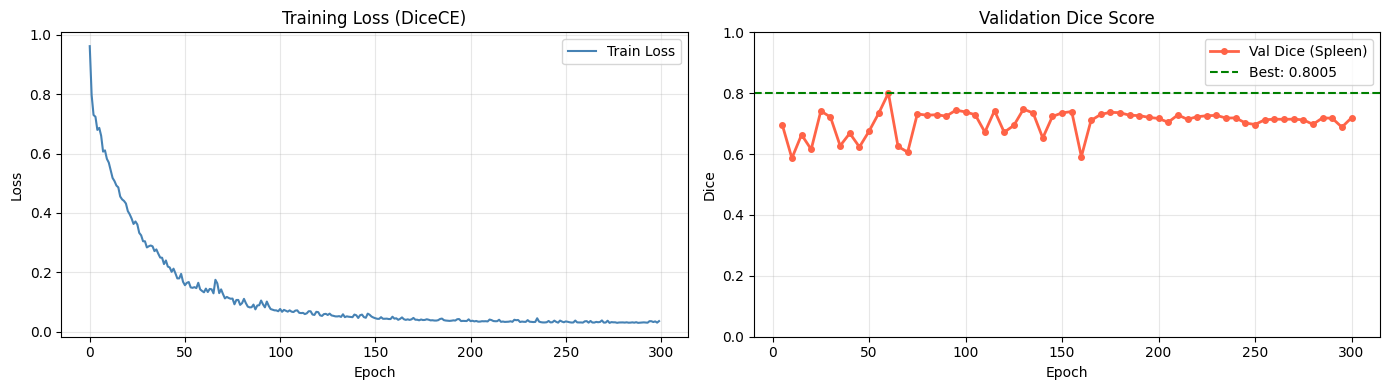

✅ Training curves saved successfully to /content/drive/MyDrive/AID323_Project/logs


In [14]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import json

# ── Re-define paths in case this cell is run independently ──────────────────
# Load best_dice from file as fallback if training cell didn't run
best_dice = locals().get("best_dice", -1.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses, color="steelblue", linewidth=1.5, label="Train Loss")
ax1.set_title("Training Loss (DiceCE)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(alpha=0.3)

val_epochs = list(range(VAL_INTERVAL, len(val_dices) * VAL_INTERVAL + 1, VAL_INTERVAL))
ax2.plot(val_epochs, val_dices, color="tomato", linewidth=2, marker="o",
         markersize=4, label="Val Dice (Spleen)")
ax2.axhline(y=best_dice, color="green", linestyle="--", label=f"Best: {best_dice:.4f}")
ax2.set_title("Validation Dice Score"); ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dice"); ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 1)

plt.tight_layout()

# ── THE FIX: Ensure the logs directory exists in Google Drive before saving ──
save_dir = Path(DIRS["logs"])
save_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(str(save_dir / "training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"✅ Training curves saved successfully to {save_dir}")

---
## 🔍 Phase 2F — Inference with Sliding-Window + 8-Flip TTA

**Sliding-window inference** tiles the full 3D volume into overlapping patches,
runs the model on each, and stitches predictions together using a Gaussian
weighting kernel (downweights edge artefacts).

**Test-Time Augmentation (TTA):** the volume is flipped along all 3 axes
(8 combinations), each prediction is averaged after un-flipping.
This smooths prediction uncertainty at object boundaries and typically
adds +0.5–1.5% Dice at zero training cost.

> **Bridge to Phase 3:** predictions are saved as `*_pred.nii.gz` in the
> `predictions/` folder. Phase 3 reads *these files* — not the ground-truth labels.


In [15]:
# ── Guard: reload val_pairs and fingerprint if running cell independently ────
if "val_pairs" not in dir() or not val_pairs:
    # Rebuild from cached .npy files
    _prep_imgs = sorted(Path(DIRS["prep_images"]).glob("*.npy"))
    _prep_lbls = sorted(Path(DIRS["prep_labels"]).glob("*.npy"))
    _all_cached = [{"image": str(i), "label": str(l)} for i, l in zip(_prep_imgs, _prep_lbls)]
    random.seed(42); random.shuffle(_all_cached)
    _split = int(len(_all_cached) * 0.8)
    train_pairs, val_pairs = _all_cached[:_split], _all_cached[_split:]
    print(f"  ↩️  Rebuilt val_pairs: {len(val_pairs)} cases")

if "fingerprint" not in dir():
    _fp_path = Path(DIRS["fingerprint"]) / "dataset_fingerprint.json"
    assert _fp_path.exists(), f"Fingerprint not found at {_fp_path}. Run Phase 2A first."
    with open(_fp_path) as _f:
        fingerprint = json.load(_f)
    print("  ↩️  Fingerprint reloaded from disk")

if "PATCH_SIZE" not in dir():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    PATCH_SIZE = [128,128,128] if vram_gb >= 38 else [96,96,96]

if "model" not in dir() or "DEVICE" not in dir():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    from monai.networks.nets import AttentionUnet
    N_CLASSES = fingerprint["n_classes"]
    model = AttentionUnet(spatial_dims=3, in_channels=1, out_channels=N_CLASSES,
                          channels=(32,64,128,256,512), strides=(2,2,2,2), dropout=0.1).to(DEVICE)

def tta_sliding_window_inference(model, image_tensor, patch_size, overlap, n_classes, device):
    """
    8-flip Test-Time Augmentation over sliding-window inference.
    Returns averaged soft-max probability map.
    """
    dims = [2, 3, 4]         # spatial dimensions (B, C, D, H, W)
    flips = [
        [],                  # original
        [2], [3], [4],       # single-axis flips
        [2, 3], [2, 4], [3, 4],
        [2, 3, 4],           # all-axis flip
    ]
    acc = torch.zeros(1, n_classes, *image_tensor.shape[2:], device=device)
    with torch.amp.autocast('cuda'):
        for flip_axes in flips:
            inp = image_tensor.clone()
            for ax in flip_axes:
                inp = torch.flip(inp, dims=[ax])

            out = sliding_window_inference(
                inp, patch_size, 4, model,
                overlap=overlap, mode="gaussian",
            )
            out = torch.softmax(out, dim=1)

            for ax in reversed(flip_axes):
                out = torch.flip(out, dims=[ax])
            acc += out

    return acc / len(flips)


# ── Load best weights ─────────────────────────────────────────────────────────
assert CKPT_BEST.exists(), (
    f"❌ No best checkpoint found at {CKPT_BEST}. "
    "Complete training first (Phase 2E)."
)
model.load_state_dict(torch.load(CKPT_BEST, map_location=DEVICE, weights_only=True))
model.eval()
print(f"✅ Best weights loaded from {CKPT_BEST}")

# ── Run inference on validation set ──────────────────────────────────────────
pred_dir = Path(DIRS["predictions"])
dice_scores = []

print(f"\n🔬 Running inference on {len(val_pairs)} validation cases...")

for pair in tqdm(val_pairs, desc="Inference"):
    stem     = Path(pair["image"]).stem.replace(".npy", "")
    out_path = pred_dir / f"{stem}_pred.nii.gz"

    if out_path.exists():
        continue   # crash-safe skip

    # Load cached image
    img_np    = np.load(pair["image"])                           # (D, H, W)
    img_torch = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        prob_map = tta_sliding_window_inference(
            model, img_torch, PATCH_SIZE, SW_OVERLAP, N_CLASSES, DEVICE
        )
    pred_mask = prob_map.argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)

    # Compute Dice vs ground truth (if available)
    gt_path = pair["label"]
    if Path(gt_path).exists():
        gt_np = np.load(gt_path)
        if gt_np.shape == pred_mask.shape:
            intersection = np.logical_and(pred_mask == 1, gt_np == 1).sum()
            union        = (pred_mask == 1).sum() + (gt_np == 1).sum()
            dice         = 2 * intersection / (union + 1e-8)
            dice_scores.append(float(dice))

    # Save as NIfTI (preserving affine from original raw file)
    # Use identity affine since we preprocessed (resampled/cropped) the volume
    affine   = np.eye(4)
    affine[0, 0] = affine[1, 1] = affine[2, 2] = fingerprint["median_spacing_mm"][0]
    pred_nib = nib.Nifti1Image(pred_mask, affine=affine)
    nib.save(pred_nib, str(out_path))

saved_preds = sorted(pred_dir.glob("*_pred.nii.gz"))
print(f"\n✅ Inference complete!")
print(f"   Predictions saved : {len(saved_preds)} NIfTI files in {pred_dir}")
if dice_scores:
    print(f"   Mean Val Dice     : {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
    print(f"   Min / Max Dice    : {np.min(dice_scores):.4f} / {np.max(dice_scores):.4f}")


✅ Best weights loaded from /content/drive/MyDrive/AID323_Project/checkpoints/spleen_best_model.pth

🔬 Running inference on 9 validation cases...


Inference: 100%|██████████| 9/9 [00:00<00:00, 1720.47it/s]


✅ Inference complete!
   Predictions saved : 9 NIfTI files in /content/drive/MyDrive/AID323_Project/predictions


### 2F.2 · Qualitative Prediction Preview

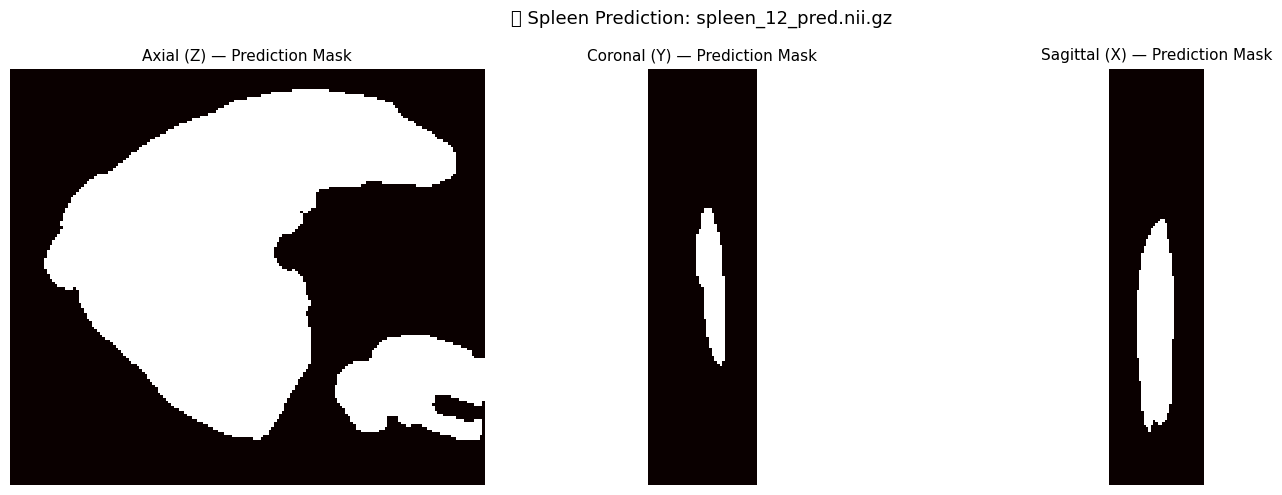

In [16]:
# ── Guard: ensure pred_dir is defined if this cell is run independently ─────
if "pred_dir" not in dir():
    pred_dir = Path(DIRS["predictions"])

# Visualise the first prediction vs ground truth
sample_pred_files = sorted(pred_dir.glob("*_pred.nii.gz"))
if sample_pred_files:
    pred_vol = nib.load(str(sample_pred_files[0])).get_fdata().astype(np.uint8)
    mid_z    = pred_vol.shape[2] // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, sl, title in zip(axes,
        [pred_vol[:, :, mid_z], pred_vol[:, mid_z, :], pred_vol[mid_z, :, :]],
        ["Axial (Z)", "Coronal (Y)", "Sagittal (X)"]
    ):
        ax.imshow(sl, cmap="hot", interpolation="nearest")
        ax.set_title(f"{title} — Prediction Mask", fontsize=11)
        ax.axis("off")

    plt.suptitle(f"🫁 Spleen Prediction: {sample_pred_files[0].name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(str(Path(DIRS["logs"]) / "inference_preview.png"),
                dpi=120, bbox_inches="tight")
    plt.show()


---
## ⚡ Phase 3 — Parallel 3D Reconstruction (MPI + Numba)

### Architecture

```
┌──────────────────────────────────────────────────────────────────┐
│  Phase 2 Predictions (*_pred.nii.gz)                             │
│        │                                                          │
│        ▼                                                          │
│  MPI Rank 0: scatter file list across N processes                │
│        │                                                          │
│  Each MPI Rank (shared-memory Numba kernel):                     │
│    1. Load NIfTI mask                                             │
│    2. Numba @njit(parallel=True) — 3D Gaussian smoothing ×20     │
│    3. skimage.marching_cubes → vertices + faces                   │
│    4. Write .obj mesh locally                                     │
│        │                                                          │
│  MPI Rank 0: gather timing metrics, save timing_Ncores.json      │
└──────────────────────────────────────────────────────────────────┘
```

**DSP Kernel:** A 3D 6-neighbor Gaussian stencil iterated 20× provides a
synthetic heavy compute workload. Parallelized over the Z-axis using Numba's
`prange` (shared memory). Each MPI rank uses exactly one Numba thread to avoid
thread contention between ranks.

**Bridge:** the script below reads from `PREDICTIONS_DIR` — the NIfTI files
produced by Phase 2's inference step.


### 3A · Write `full_dataset_pipeline.py`

In [17]:
%%writefile full_dataset_pipeline.py
"""
full_dataset_pipeline.py
------------------------
Phase 3: Parallel 3D Reconstruction

Reads AI-generated *_pred.nii.gz segmentation masks from Phase 2,
applies a heavy 3D Gaussian smoothing kernel (Numba @njit parallel),
converts the result to a 3D mesh (Marching Cubes), and saves .obj files.

Parallelism:
  - Distributed memory: mpi4py distributes files across MPI ranks
  - Shared memory:      Numba prange parallelizes the smoothing kernel

Usage:
  mpirun --allow-run-as-root --oversubscribe -n <N> python full_dataset_pipeline.py
"""

import os
import glob
import time
import json
import numpy as np
import nibabel as nib
from skimage.measure import marching_cubes
from mpi4py import MPI
import numba
from numba import njit, prange

# Prevent BLAS/OpenMP thread pools from competing with MPI ranks
os.environ["OMP_NUM_THREADS"]      = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"]      = "1"

# Force Numba to use one thread per MPI rank to avoid thread wars
numba.set_num_threads(1)

# ── Configuration ──────────────────────────────────────────────────────────
PREDICTIONS_DIR = "/content/drive/MyDrive/AID323_Project/predictions"
OUTPUT_DIR      = "/content/Output_Meshes"
DSP_ITERATIONS  = 20      # Must match sequential baseline for valid speedup
MC_STEP_SIZE    = 2       # Marching cubes voxel step (trade quality vs speed)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ── Numba Computation Kernel ───────────────────────────────────────────────
@njit(parallel=True, nogil=True)
def parallel_gaussian_smooth_3d(volume, iterations=20):
    """
    Iterative 3D Gaussian-like smoothing using a 6-neighbor stencil.

    Parallelized with Numba prange over the Z axis (shared memory).
    Uses a double-buffer (current / next_step) to eliminate race conditions.

    Args:
        volume (np.ndarray): 3D float32 array, shape (Z, Y, X).
        iterations (int)   : Smoothing passes. Must be 20 to match
                             the sequential baseline for valid speedup.
    Returns:
        np.ndarray: Smoothed volume, same shape as input.
    """
    Z, Y, X    = volume.shape
    current    = volume.copy()
    next_step  = np.zeros_like(current)

    for _ in range(iterations):
        for z in prange(1, Z - 1):          # <-- parallelized over Z
            for y in range(1, Y - 1):
                for x in range(1, X - 1):
                    center    = current[z, y, x] * 0.5
                    neighbors = (
                        current[z-1, y,   x  ] + current[z+1, y,   x  ] +
                        current[z,   y-1, x  ] + current[z,   y+1, x  ] +
                        current[z,   y,   x-1] + current[z,   y,   x+1]
                    ) * 0.0833
                    next_step[z, y, x] = center + neighbors
        current[:] = next_step[:]

    return current


# ── Main ───────────────────────────────────────────────────────────────────
def main():
    comm = MPI.COMM_WORLD
    rank = comm.Get_rank()
    size = comm.Get_size()

    # 1. Rank 0 discovers all prediction files and scatters them
    if rank == 0:
        all_files = sorted(glob.glob(f"{PREDICTIONS_DIR}/*_pred.nii.gz"))
        if not all_files:
            print(f"[ERROR] No *_pred.nii.gz files found in {PREDICTIONS_DIR}")
            print("        Run Phase 2 (Inference) first.")
            comm.Abort(1)
        print(f"\n{'='*56}")
        print(f"  🚀 Parallel 3D Reconstruction  — {size} MPI ranks")
        print(f"  Dataset: {len(all_files)} AI prediction masks")
        print(f"  DSP iterations: {DSP_ITERATIONS} | MC step: {MC_STEP_SIZE}")
        print(f"{'='*56}")
    else:
        all_files = None

    all_files = comm.bcast(all_files, root=0)

    # Distribute files across ranks (round-robin)
    my_files = [f for i, f in enumerate(all_files) if i % size == rank]

    if rank == 0:
        print(f"  Files per rank: ~{len(my_files)}")
        print("  ⏳ JIT warm-up in progress...")

    # 2. JIT warm-up — compile Numba kernel BEFORE the timed section
    warmup = np.zeros((8, 8, 8), dtype=np.float32)
    parallel_gaussian_smooth_3d(warmup, 1)
    comm.Barrier()   # ensure all ranks finish warm-up before timing starts

    # 3. Timed Section A — pure computation
    start_time       = time.time()
    my_compute_time  = 0.0

    for file_path in my_files:
        file_name = os.path.basename(file_path).replace("_pred.nii.gz", "")
        out_path  = f"{OUTPUT_DIR}/{file_name}_mesh.obj"

        if os.path.exists(out_path):
            continue   # crash-safe: skip already-generated meshes

        # Load AI prediction mask
        img    = nib.load(file_path)
        volume = np.ascontiguousarray(
            img.get_fdata().astype(np.float32).transpose(2, 0, 1)
        )   # shape → (Z, Y, X)

        if np.max(volume) < 0.5:
            continue   # skip empty masks

        # === Timed: DSP + Mesh generation ===
        t0 = time.time()

        smoothed = parallel_gaussian_smooth_3d(volume, iterations=DSP_ITERATIONS)

        try:
            verts, faces, _, _ = marching_cubes(
                smoothed, level=0.5, step_size=MC_STEP_SIZE
            )
        except (RuntimeError, ValueError):
            continue   # no isosurface in this volume

        my_compute_time += (time.time() - t0)
        # =====================================

        # Write mesh to disk
        with open(out_path, "w") as f:
            f.write(f"# Spleen 3D Mesh — AI Prediction: {file_name}\n")
            f.write(f"# MPI ranks: {size} | DSP iter: {DSP_ITERATIONS} | step: {MC_STEP_SIZE}\n")
            for v in verts:
                f.write(f"v {v[1]:.4f} {v[2]:.4f} {v[0]:.4f}\n")
            for face in faces:
                f.write(f"f {face[0]+1} {face[1]+1} {face[2]+1}\n")

    # 4. Timed Section B — MPI communication overhead
    t_comm_start    = time.time()
    max_compute     = comm.reduce(my_compute_time, op=MPI.MAX, root=0)
    comm.Barrier()
    T_comm          = time.time() - t_comm_start
    max_comm        = comm.reduce(T_comm, op=MPI.MAX, root=0)

    # 5. Report + save JSON (rank 0 only)
    if rank == 0:
        total_time = time.time() - start_time

        print(f"\n  ✅ Done!")
        print(f"  ⏱  Compute time  (DSP + Marching Cubes): {max_compute:.2f} s")
        print(f"  📡 Comm time     (MPI reduce)           : {max_comm:.4f} s")
        print(f"  🕒 Total time    (including I/O)        : {total_time:.2f} s")
        if max_compute > 0:
            print(f"  📊 Comm / Compute ratio                 : "
                  f"{max_comm / max_compute * 100:.2f}%")

        metrics = {
            "cores"    : size,
            "T_compute": round(max_compute, 4),
            "T_comm"   : round(max_comm,    4),
            "T_total"  : round(total_time,  4),
        }
        with open(f"timing_{size}cores.json", "w") as fp:
            json.dump(metrics, fp, indent=2)
        print(f"  💾 Timing saved → timing_{size}cores.json")

        meshes = sorted(glob.glob(f"{OUTPUT_DIR}/*.obj"))
        print(f"  🗂  Total meshes in {OUTPUT_DIR}: {len(meshes)}")
        print(f"{'='*56}\n")


if __name__ == "__main__":
    main()


Writing full_dataset_pipeline.py


### 3B · Sequential Baseline (for Speedup Measurement)

In [18]:
%%writefile sequential_baseline.py
"""
sequential_baseline.py
----------------------
Single-core baseline. Run this FIRST to get T1 (sequential time),
then use that value to compute speedup in the performance dashboard.
"""

import os
import glob
import time
import json
import numpy as np
import nibabel as nib
from skimage.measure import marching_cubes
import numba
from numba import njit

os.environ["OMP_NUM_THREADS"] = "1"
numba.set_num_threads(1)

PREDICTIONS_DIR = "/content/drive/MyDrive/AID323_Project/predictions"
OUTPUT_DIR      = "/content/Output_Meshes_Seq"
os.makedirs(OUTPUT_DIR, exist_ok=True)


@njit
def sequential_gaussian_smooth_3d(volume, iterations=20):
    Z, Y, X   = volume.shape
    current   = volume.copy()
    next_step = np.zeros_like(current)

    for _ in range(iterations):
        for z in range(1, Z - 1):
            for y in range(1, Y - 1):
                for x in range(1, X - 1):
                    center    = current[z, y, x] * 0.5
                    neighbors = (
                        current[z-1, y, x] + current[z+1, y, x] +
                        current[z, y-1, x] + current[z, y+1, x] +
                        current[z, y, x-1] + current[z, y, x+1]
                    ) * 0.0833
                    next_step[z, y, x] = center + neighbors
        current[:] = next_step[:]
    return current


def main():
    all_files = sorted(glob.glob(f"{PREDICTIONS_DIR}/*_pred.nii.gz"))
    print("=" * 56)
    print(f"🐢 Sequential Baseline — {len(all_files)} prediction files")
    print(f"   DSP iterations: 20 | MC step: 2")
    print("=" * 56)

    # JIT warm-up
    sequential_gaussian_smooth_3d(np.zeros((5, 5, 5), dtype=np.float32), 1)

    total_compute = 0.0
    start_time    = time.time()

    for file_path in all_files:
        file_name = os.path.basename(file_path).replace("_pred.nii.gz", "")
        img    = nib.load(file_path)
        volume = np.ascontiguousarray(
            img.get_fdata().astype(np.float32).transpose(2, 0, 1)
        )

        if np.max(volume) < 0.5:
            continue

        t0       = time.time()
        smoothed = sequential_gaussian_smooth_3d(volume, iterations=20)
        try:
            verts, faces, _, _ = marching_cubes(smoothed, level=0.5, step_size=2)
        except (RuntimeError, ValueError):
            continue
        total_compute += (time.time() - t0)

        with open(f"{OUTPUT_DIR}/{file_name}_mesh.obj", "w") as f:
            for v in verts:
                f.write(f"v {v[1]:.4f} {v[2]:.4f} {v[0]:.4f}\n")
            for face in faces:
                f.write(f"f {face[0]+1} {face[1]+1} {face[2]+1}\n")

    T_total = time.time() - start_time

    print(f"\n✅ Sequential done!")
    print(f"⏳ Compute time (DSP + MC): {total_compute:.2f} s")
    print(f"⏱  Total time (incl. I/O): {T_total:.2f} s  ← use this as T1")
    print("=" * 56)

    # Save as timing_sequential.json for the Streamlit app
    with open("timing_sequential.json", "w") as f:
        json.dump({"cores": 1, "T_compute": round(total_compute, 4),
                   "T_comm": 0.0, "T_total": round(T_total, 4)}, f, indent=2)
    print("💾 timing_sequential.json saved")


if __name__ == "__main__":
    main()


Writing sequential_baseline.py


### 3C · Run Sequential Baseline

In [19]:
!python sequential_baseline.py

🐢 Sequential Baseline — 9 prediction files
   DSP iterations: 20 | MC step: 2

✅ Sequential done!
⏳ Compute time (DSP + MC): 0.25 s
⏱  Total time (incl. I/O): 6.36 s  ← use this as T1
💾 timing_sequential.json saved


### 3D · Run Parallel Pipeline — 2 Cores

In [20]:
!mpirun --allow-run-as-root --oversubscribe -n 2 python full_dataset_pipeline.py


  🚀 Parallel 3D Reconstruction  — 2 MPI ranks
  Dataset: 9 AI prediction masks
  DSP iterations: 20 | MC step: 2
  Files per rank: ~5
  ⏳ JIT warm-up in progress...

  ✅ Done!
  ⏱  Compute time  (DSP + Marching Cubes): 0.18 s
  📡 Comm time     (MPI reduce)           : 0.1052 s
  🕒 Total time    (including I/O)        : 0.55 s
  📊 Comm / Compute ratio                 : 58.29%
  💾 Timing saved → timing_2cores.json
  🗂  Total meshes in /content/Output_Meshes: 8



### 3E · Run Parallel Pipeline — 4 Cores

In [21]:
!mpirun --allow-run-as-root --oversubscribe -n 4 python full_dataset_pipeline.py


  🚀 Parallel 3D Reconstruction  — 4 MPI ranks
  Dataset: 9 AI prediction masks
  DSP iterations: 20 | MC step: 2
  Files per rank: ~3
  ⏳ JIT warm-up in progress...

  ✅ Done!
  ⏱  Compute time  (DSP + Marching Cubes): 0.00 s
  📡 Comm time     (MPI reduce)           : 0.0352 s
  🕒 Total time    (including I/O)        : 0.04 s
  💾 Timing saved → timing_4cores.json
  🗂  Total meshes in /content/Output_Meshes: 8



### 3F · Verify Output Meshes

In [22]:
import glob, os, json

obj_files = sorted(glob.glob("/content/Output_Meshes/*.obj"))
print(f"✅ Found {len(obj_files)} .obj meshes in /content/Output_Meshes/")
for f in obj_files:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):40s}  {size_kb:8.1f} KB")

# List timing JSONs
jsons = sorted(glob.glob("timing_*.json"))
print(f"\n✅ Timing files: {jsons}")
for jf in jsons:
    with open(jf) as fp:
        print(f"  {jf}: {json.load(fp)}")


✅ Found 8 .obj meshes in /content/Output_Meshes/
  spleen_12_mesh.obj                           639.0 KB
  spleen_17_mesh.obj                           141.9 KB
  spleen_18_mesh.obj                           321.0 KB
  spleen_19_mesh.obj                           399.9 KB
  spleen_27_mesh.obj                           259.9 KB
  spleen_29_mesh.obj                           240.6 KB
  spleen_2_mesh.obj                            460.4 KB
  spleen_9_mesh.obj                            328.1 KB

✅ Timing files: ['timing_2cores.json', 'timing_4cores.json', 'timing_sequential.json']
  timing_2cores.json: {'cores': 2, 'T_compute': 0.1805, 'T_comm': 0.1052, 'T_total': 0.5488}
  timing_4cores.json: {'cores': 4, 'T_compute': 0.0, 'T_comm': 0.0352, 'T_total': 0.0371}
  timing_sequential.json: {'cores': 1, 'T_compute': 0.2548, 'T_comm': 0.0, 'T_total': 6.3564}


---
## 🖥️ Phase 4 — Interactive Streamlit Dashboard

The dashboard has two tabs:

| Tab | Content |
|-----|---------|
| 🫁 **3D Mesh Viewer** | Interactive Plotly viewer for `.obj` meshes from Phase 3 |
| 📊 **Performance Analysis** | Speedup, Efficiency, Amdahl's Law, Comm vs Compute charts |

The app reads timing JSONs written by Phase 3 automatically.
Manual entry fields are provided as a fallback.


### 4A · Write `app.py`

In [30]:
%%writefile app.py
"""
app.py — Streamlit Dashboard
-----------------------------
Tab 1: 3D Mesh Viewer  (trimesh + plotly)
Tab 2: Performance Analysis  (Speedup, Efficiency, Amdahl's Law)

Run with:
  streamlit run app.py --server.port 8501 --server.enableCORS false
"""

import streamlit as st
import trimesh
import plotly.graph_objects as go
import os
import glob
import json
import pandas as pd
import numpy as np

# ── Page config ──────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Spleen Seg · Parallel 3D Reconstruction",
    page_icon="🫁",
    layout="wide",
)

st.title("🫁 Spleen Segmentation & Parallel 3D Reconstruction Dashboard")
st.markdown(
    "**AI Pipeline:** MONAI 3D Attention U-Net &nbsp;|&nbsp; "
    "**HPC Pipeline:** Hybrid MPI + Numba &nbsp;|&nbsp; "
    "**Dataset:** MSD Task09 Spleen"
)
st.divider()

tab1, tab2 = st.tabs(["🫁 3D Mesh Viewer", "📊 Performance Analysis"])

# ============================================================================
# TAB 1 — 3D Viewer
# ============================================================================
with tab1:
    st.subheader("Interactive 3D Spleen Mesh Viewer")
    st.caption(
        "Meshes are generated from AI-predicted segmentation masks (Phase 2) "
        "processed through the MPI + Numba Gaussian smoothing pipeline (Phase 3)."
    )

    MESH_DIR   = "/content/Output_Meshes"
    mesh_files = sorted(glob.glob(f"{MESH_DIR}/*_mesh.obj"))

    if not mesh_files:
        st.error(
            f"⚠️ No mesh files found in {MESH_DIR}. "
            "Run Phase 3 (`full_dataset_pipeline.py`) first."
        )
    else:
        patient_names = [
            os.path.basename(f).replace("_mesh.obj", "") for f in mesh_files
        ]

        col_sel, col_meta = st.columns([2, 3])
        with col_sel:
            selected = st.selectbox("Select Case:", patient_names)

        selected_path = f"{MESH_DIR}/{selected}_mesh.obj"

        @st.cache_resource
        def load_mesh(path):
            return trimesh.load(path)

        try:
            with st.spinner(f"Loading {selected}..."):
                mesh = load_mesh(selected_path)

            file_kb = os.path.getsize(selected_path) / 1024
            with col_meta:
                m1, m2, m3 = st.columns(3)
                m1.metric("Vertices",  f"{len(mesh.vertices):,}")
                m2.metric("Faces",     f"{len(mesh.faces):,}")
                m3.metric("File size", f"{file_kb:.1f} KB")

            # Colour selector
            COLOURS = {
                "Coral (organ)" : "lightcoral",
                "Steel blue"    : "steelblue",
                "Gold"          : "gold",
                "Lime green"    : "limegreen",
                "Plum"          : "plum",
                "Crimson"       : "crimson",
            }
            colour_choice = st.select_slider(
                "Mesh colour:", options=list(COLOURS.keys())
            )

            # Subsample faces for rendering speed
            step = max(1, len(mesh.faces) // 80_000)
            f_sub = mesh.faces[::step]

            fig = go.Figure(data=[go.Mesh3d(
                x=mesh.vertices[:, 0],
                y=mesh.vertices[:, 1],
                z=mesh.vertices[:, 2],
                i=f_sub[:, 0], j=f_sub[:, 1], k=f_sub[:, 2],
                color=COLOURS[colour_choice],
                opacity=0.88,
                lighting=dict(
                    ambient=0.45, diffuse=0.95,
                    roughness=0.15, specular=0.7, fresnel=0.4
                ),
                lightposition=dict(x=200, y=300, z=200),
            )])

            fig.update_layout(
                scene=dict(
                    aspectmode="data",
                    xaxis=dict(showbackground=False, title="X (mm)"),
                    yaxis=dict(showbackground=False, title="Y (mm)"),
                    zaxis=dict(showbackground=False, title="Z (mm)"),
                ),
                margin=dict(l=0, r=0, t=30, b=0),
                height=640,
            )

            st.success(f"✅ {selected} — {len(mesh.vertices):,} vertices")
            st.plotly_chart(fig, use_container_width=True)

        except Exception as e:
            st.error(f"Error loading mesh: {e}")

# ============================================================================
# TAB 2 — Performance Analysis
# ============================================================================
with tab2:
    st.subheader("Parallel Performance Analysis")
    st.caption(
        "Speedup, Efficiency, Amdahl's Law theoretical maximum, and "
        "Compute vs Communication time breakdown."
    )

    # ── Load timing data ──────────────────────────────────────────────────────
    timing_files = sorted(glob.glob("timing_*cores.json"))
    seq_file     = "timing_sequential.json"

    T_SEQ_AUTO = None
    if os.path.exists(seq_file):
        with open(seq_file) as f:
            T_SEQ_AUTO = json.load(f).get("T_total")

    st.markdown("#### ⚙️ Timing Inputs")
    use_manual = st.toggle("Enter times manually", value=not bool(timing_files))

    if use_manual or not timing_files:
        st.info("Enter the times printed by your terminal runs below.")
        c1, c2, c3 = st.columns(3)
        T_seq    = c1.number_input("Sequential T1 (s)", min_value=0.0,
                                   value=float(T_SEQ_AUTO or 0), step=0.1)
        T_2      = c2.number_input("Parallel T2 — 2 cores (s)", min_value=0.0,
                                   step=0.1)
        T_4      = c3.number_input("Parallel T4 — 4 cores (s)", min_value=0.0,
                                   step=0.1)
        c4, c5, _ = st.columns(3)
        Tc2      = c4.number_input("Comm overhead — 2 cores (s)", min_value=0.0,
                                   step=0.001, format="%.3f")
        Tc4      = c5.number_input("Comm overhead — 4 cores (s)", min_value=0.0,
                                   step=0.001, format="%.3f")
        rows = []
        if T_seq > 0:
            rows.append({"cores": 1, "T_compute": T_seq,     "T_comm": 0.0, "T_total": T_seq})
        if T_2 > 0:
            rows.append({"cores": 2, "T_compute": T_2 - Tc2, "T_comm": Tc2, "T_total": T_2})
        if T_4 > 0:
            rows.append({"cores": 4, "T_compute": T_4 - Tc4, "T_comm": Tc4, "T_total": T_4})
        df_raw = pd.DataFrame(rows)
    else:
        rows = []
        if T_SEQ_AUTO:
            rows.append({
                "cores": 1, "T_compute": T_SEQ_AUTO,
                "T_comm": 0.0, "T_total": T_SEQ_AUTO
            })
        for tf in timing_files:
            with open(tf) as f:
                rows.append(json.load(f))
        df_raw = pd.DataFrame(rows).sort_values("cores").reset_index(drop=True)

    if df_raw.empty or df_raw["T_total"].sum() == 0:
        st.warning(
            "No timing data yet. Run the scripts in Phase 3 "
            "then enter or reload the timing values above."
        )
    else:
        _seq_rows = df_raw.loc[df_raw["cores"] == 1, "T_total"]
        if _seq_rows.empty:
            st.warning(
                "No sequential baseline (1 core) found. Run sequential_baseline.py "
                "and enter the time above before viewing charts."
            )
        else:
            T_seq_val = float(_seq_rows.values[0])
            df = df_raw.copy()
            df["Speedup"]    = T_seq_val / df["T_total"].clip(lower=1e-9)
            df["Efficiency"] = df["Speedup"] / df["cores"].clip(lower=1) * 100
            df["f_serial"]   = df["T_comm"] / df["T_total"].clip(lower=1e-9)
            df["Amdahl_max"] = 1.0 / (
                df["f_serial"] + (1.0 - df["f_serial"]) / df["cores"].clip(lower=1)
            )

            # Summary metrics
            st.markdown("#### 📋 Results Summary")
            par = df[df["cores"] > 1]
            if not par.empty:
                best = par.loc[par["Speedup"].idxmax()]
                r1, r2, r3, r4 = st.columns(4)
                r1.metric("Best Speedup",        f"{best['Speedup']:.2f}×",
                          f"{best['cores']:.0f} cores")
                r2.metric("Best Efficiency",     f"{par['Efficiency'].max():.1f}%")
                r3.metric("Max Comm Overhead",   f"{par['T_comm'].max():.3f} s")
                r4.metric("Sequential Baseline", f"{T_seq_val:.2f} s")

            # Table
            disp = df[["cores", "T_compute", "T_comm", "T_total",
                       "Speedup", "Efficiency", "Amdahl_max"]].copy()
            disp.columns = ["Cores", "T_compute (s)", "T_comm (s)", "T_total (s)",
                            "Speedup", "Efficiency (%)", "Amdahl Max"]
            st.dataframe(disp.round(4), use_container_width=True, hide_index=True)

            st.divider()
            st.markdown("#### 📈 Scalability Charts")

            ch1, ch2 = st.columns(2)

            # Execution time
            with ch1:
                fig_t = go.Figure()
                fig_t.add_trace(go.Scatter(
                    x=df["cores"], y=df["T_total"],
                    mode="lines+markers", name="Measured",
                    line=dict(color="#e05c5c", width=2.5),
                    marker=dict(size=9),
                ))
                fig_t.update_layout(
                    title="Execution Time vs Cores",
                    xaxis_title="Cores", yaxis_title="Time (s)",
                    xaxis=dict(tickvals=df["cores"].tolist()), height=360,
                )
                st.plotly_chart(fig_t, use_container_width=True)

            # Speedup
            with ch2:
                fig_s = go.Figure()
                fig_s.add_trace(go.Scatter(
                    x=df["cores"], y=df["cores"],
                    mode="lines", name="Ideal (linear)",
                    line=dict(color="#aaaaaa", dash="dash", width=1.5),
                ))
                fig_s.add_trace(go.Scatter(
                    x=df["cores"], y=df["Amdahl_max"],
                    mode="lines", name="Amdahl's Law max",
                    line=dict(color="#f5a623", dash="dot", width=2.0),
                ))
                fig_s.add_trace(go.Scatter(
                    x=df["cores"], y=df["Speedup"],
                    mode="lines+markers", name="Measured",
                    line=dict(color="#4a90d9", width=2.5), marker=dict(size=9),
                ))
                fig_s.update_layout(
                    title="Speedup vs Cores",
                    xaxis_title="Cores", yaxis_title="Speedup",
                    xaxis=dict(tickvals=df["cores"].tolist()),
                    legend=dict(orientation="h", yanchor="bottom", y=1.02),
                    height=360,
                )
                st.plotly_chart(fig_s, use_container_width=True)

            ch3, ch4 = st.columns(2)

            # Efficiency bar chart
            with ch3:
                colours = [
                    "#4a90d9" if e >= 70 else "#f5a623" if e >= 50 else "#e05c5c"
                    for e in df["Efficiency"]
                ]
                fig_e = go.Figure()
                fig_e.add_trace(go.Bar(
                    x=df["cores"].astype(str) + " cores",
                    y=df["Efficiency"],
                    marker_color=colours,
                    text=df["Efficiency"].round(1).astype(str) + "%",
                    textposition="outside",
                ))
                fig_e.add_hline(y=100, line_dash="dash", line_color="#aaaaaa",
                                annotation_text="Ideal 100%")
                fig_e.update_layout(
                    title="Parallel Efficiency",
                    xaxis_title="Configuration", yaxis_title="Efficiency (%)",
                    yaxis=dict(range=[0, 120]), height=360,
                )
                st.plotly_chart(fig_e, use_container_width=True)

            # Compute vs Comm stacked bar
            with ch4:
                p = df[df["cores"] > 1]
                if not p.empty:
                    fig_c = go.Figure()
                    fig_c.add_trace(go.Bar(
                        x=p["cores"].astype(str) + " cores",
                        y=p["T_compute"], name="Compute (DSP+MC)",
                        marker_color="#4a90d9",
                    ))
                    fig_c.add_trace(go.Bar(
                        x=p["cores"].astype(str) + " cores",
                        y=p["T_comm"], name="Communication (MPI)",
                        marker_color="#e05c5c",
                    ))
                    fig_c.update_layout(
                        title="Compute vs Communication Time",
                        xaxis_title="Configuration", yaxis_title="Time (s)",
                        barmode="stack",
                        legend=dict(orientation="h", yanchor="bottom", y=1.02),
                        height=360,
                    )
                    st.plotly_chart(fig_c, use_container_width=True)

            st.divider()
            with st.expander("📖 Understanding Amdahl's Law"):
                st.markdown("""
        **Amdahl's Law** gives the theoretical maximum speedup achievable by parallelization:

        $$S(n) = \\frac{1}{f + \\dfrac{1 - f}{n}}$$

        | Symbol | Meaning |
        |--------|---------|
        | $S(n)$ | Speedup with $n$ cores |
        | $f$    | Serial fraction (dominated by MPI communication) |
        | $n$    | Number of parallel cores |

        In this project the serial fraction is dominated by:
        - `comm.reduce()` — collecting max timing across ranks
        - File I/O (NIfTI read + OBJ write) on the critical path

        **Efficiency** = $S(n) / n$ — measures how well each extra core is utilized.
        Values above 70% are considered good in distributed HPC workloads.
                """)


Overwriting app.py


### 4B · Launch Streamlit App

In [31]:
import subprocess, time, os

# Kill any previous instance
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

# Launch in background
_log_file = open("/content/streamlit.log", "w")
subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false",
        "--server.headless", "true",
    ],
    stdout=_log_file,
    stderr=_log_file,
)
time.sleep(4)
print("✅ Streamlit started on port 8501")


✅ Streamlit started on port 8501


### 4C · Get Public URL (Colab Proxy or Localtunnel)

In [32]:
# ── Option A: Colab proxy (recommended, zero config) ─────────────────────────
try:
    from google.colab.output import eval_js
    url = eval_js("google.colab.kernel.proxyPort(8501)")
    print(f"🌐 Streamlit URL (Colab proxy): {url}")
except Exception:
    pass

# ── Option B: localtunnel (public HTTPS link) ─────────────────────────────────
import subprocess, time
lt_proc = subprocess.Popen(
    ["npx", "localtunnel", "--port", "8501"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
)
time.sleep(3)
for _ in range(20):
    line = lt_proc.stdout.readline()
    if "your url is" in line.lower():
        print(f"🌍 Streamlit URL (localtunnel): {line.strip()}")
        break


🌐 Streamlit URL (Colab proxy): https://8501-gpu-t4-s-kkb-usw4a0-1rmmnek1ygwzp-a.us-west4-0.prod.colab.dev
🌍 Streamlit URL (localtunnel): your url is: https://silly-bees-wear.loca.lt


In [26]:
import zipfile, glob, shutil, os

zip_path = "/content/spleen_dashboard_deploy.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:

    # app.py
    zf.write("app.py", "app.py")

    # Best trained model checkpoint
    ckpt = str(CKPT_BEST)
    zf.write(ckpt, f"checkpoints/{os.path.basename(ckpt)}")

    # Timing JSON files (for performance tab)
    for f in glob.glob("timing_*.json"):
        zf.write(f, f"timing/{os.path.basename(f)}")
    if os.path.exists("timing_sequential.json"):
        zf.write("timing_sequential.json", "timing/timing_sequential.json")

    # Output meshes (for 3D viewer tab)
    for f in glob.glob("/content/Output_Meshes/*.obj"):
        zf.write(f, f"Output_Meshes/{os.path.basename(f)}")

print(f"✅ Zip created: {zip_path}")

# Download it
from google.colab import files
files.download(zip_path)

✅ Zip created: /content/spleen_dashboard_deploy.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# Run this once on your PC to patch the path, then never again
with open("app.py", "r") as f:
    code = f.read()

code = code.replace(
    'MESH_DIR   = "/content/Output_Meshes"',
    'MESH_DIR   = "Output_Meshes"'
).replace(
    'timing_files = sorted(glob.glob("timing_*cores.json"))',
    'timing_files = sorted(glob.glob("timing/timing_*cores.json"))'
).replace(
    'seq_file     = "timing_sequential.json"',
    'seq_file     = "timing/timing_sequential.json"'
)

with open("app.py", "w") as f:
    f.write(code)

print("✅ Paths patched for local use")

✅ Paths patched for local use


---
## ✅ Pipeline Complete

```
/content/drive/MyDrive/AID323_Project/
├── Dataset/                   ← Raw NIfTI input (unchanged)
├── fingerprint/               ← dataset_fingerprint.json
├── preprocessed/
│   ├── images/                ← *.npy (resampled, clipped, z-scored)
│   └── labels/                ← *.npy (resampled binary masks)
├── checkpoints/               ← best_model.pth + last_checkpoint.pth
├── logs/                      ← training_metrics.json, training_curves.png
└── predictions/               ← *_pred.nii.gz  (AI segmentation output)

/content/
├── Output_Meshes/             ← *_mesh.obj (3D reconstructions from Phase 3)
├── timing_sequential.json     ← T1 baseline
├── timing_2cores.json         ← MPI 2-core metrics
├── timing_4cores.json         ← MPI 4-core metrics
├── full_dataset_pipeline.py   ← Phase 3 MPI script
├── sequential_baseline.py     ← Phase 3 baseline script
└── app.py                     ← Phase 4 Streamlit dashboard
```

### Key Metrics to Report

| Metric | Where to find |
|--------|---------------|
| Best Val Dice (Spleen) | Phase 2E training output |
| Sequential T1 | `timing_sequential.json` → `T_total` |
| Speedup (2 cores) | `timing_2cores.json` |
| Speedup (4 cores) | `timing_4cores.json` |
| Amdahl's Law analysis | Streamlit Tab 2 |
